In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
ROOT = '..'

grain = pd.read_csv(f'{ROOT}/processed data/price_2023_enso.csv')
harvest = pd.read_csv(f'{ROOT}/processed data/yield_ljungqvist_v2.csv')
harvest['lat'] = harvest['Latitude']
harvest['lon'] = harvest['Longitude']
fish = pd.read_csv(f'{ROOT}/processed data/fishprice_enso.csv')

#create a LatLon column for grouping
for df in [grain, harvest, fish]:
    df['LatLon'] = df['Latitude'].round(2).astype(str) + ',' + df['Longitude'].round(2).astype(str)
    

In [3]:
# ── Summarise to location level ───────────────────────────────────────────────

# Grain price: one row per Location
grain_locs = (
    grain.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         teleco=('teleco_PDSI_10', 'first'))
    .reset_index()
)

# Harvest: one row per Location (collapse across grain types)
harvest_locs = (
    harvest.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         teleco=('teleco_PDSI_10', 'first'))
    .reset_index()
)

# Fish price: one row per LocationSpecies; no teleco column → set to NaN
fish_locs = (
    fish.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         Species=('Species', 'first'),
         Location=('Location', 'first'))
    .reset_index()
)
# teleco not available for fish — mark all as unknown
fish_locs['teleco'] = np.nan

print('Grain locations:', len(grain_locs))
print('Harvest locations:', len(harvest_locs))
print('Fish series (LocationSpecies):', len(fish_locs))

Grain locations: 44
Harvest locations: 86
Fish series (LocationSpecies): 8


In [4]:
# ── Plot helper ───────────────────────────────────────────────────────────────
COL_TELECO    = '#d62728'  # red  – teleconnected
COL_NONTELECO = '#1f77b4'  # blue – not teleconnected
COL_UNKNOWN   = 'black'  # grey – no teleco info

SIZE_SCALE = 0.8  # dot area = n_years * SIZE_SCALE

def plot_locs(ax, locs, jitter=0.0):
    """Scatter locations; colour by teleco status, size by n_years."""
    rng = np.random.default_rng(0)
    for _, row in locs.iterrows():
        t = row['teleco']
        if np.isnan(float(t)) if not isinstance(t, float) else np.isnan(t):
            col = COL_UNKNOWN
        elif t == 1:
            col = COL_TELECO
        else:
            col = COL_NONTELECO
        x = row['Longitude'] + rng.uniform(-jitter, jitter)
        y = row['Latitude']  + rng.uniform(-jitter, jitter)
        ax.scatter(x, y,
                   s=row['n_years'] * SIZE_SCALE,
                   color=col, edgecolors='white', linewidths=0.5,
                   alpha=0.85, transform=ccrs.PlateCarree(), zorder=3)


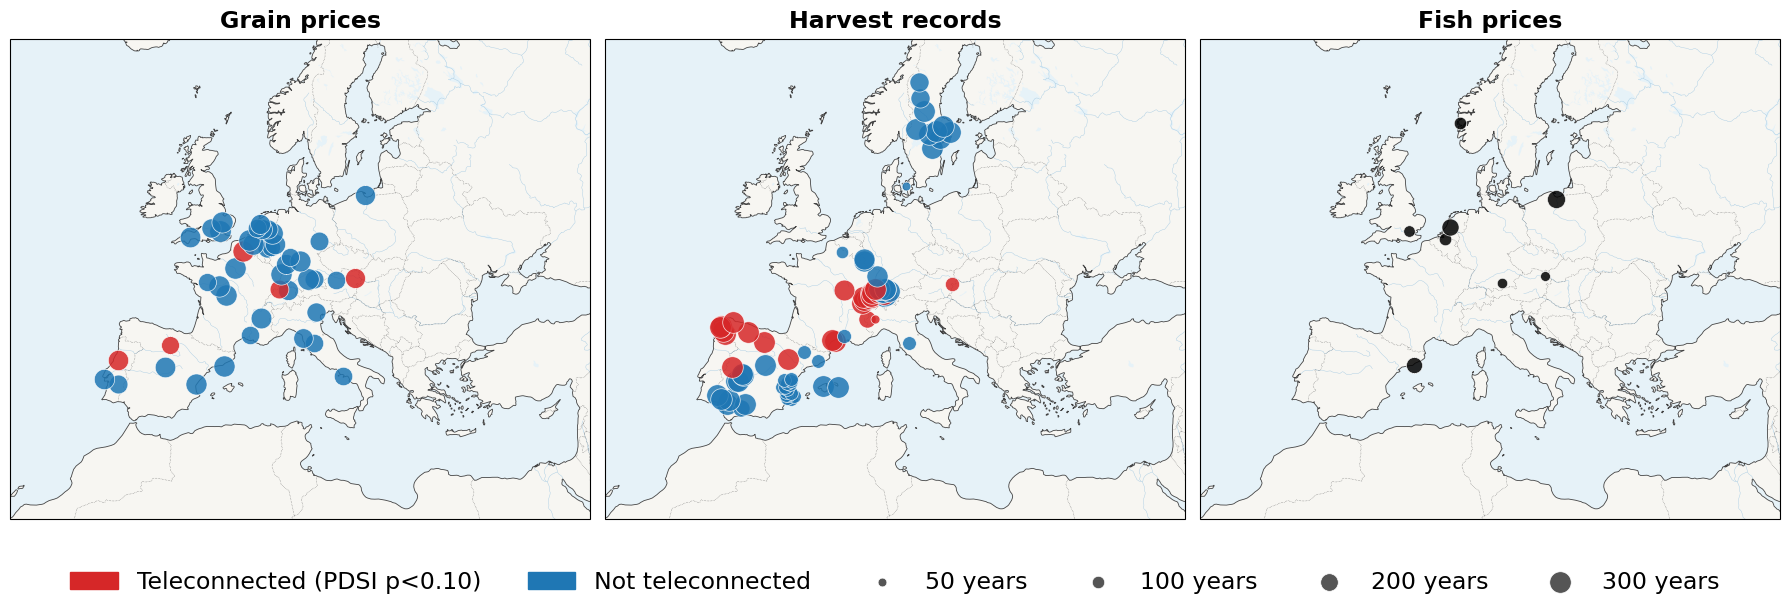

Saved map_data_coverage.pdf


In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Projection (Europe-optimized) ─────────────────────────────────────────────
proj = ccrs.LambertConformal(
    central_longitude=10,
    central_latitude=50,
    standard_parallels=(35, 65)
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={'projection': proj}
)

titles   = ['Grain prices', 'Harvest records', 'Fish prices']
datasets = [grain_locs, harvest_locs, fish_locs]

for ax, title, locs in zip(axes, titles, datasets):
    
    # Europe extent (in PlateCarree coords)
    ax.set_extent([-15, 35, 30, 65], crs=ccrs.PlateCarree())
    
    # ── Base map styling ─────────────────────────────────────────
    ax.add_feature(cfeature.LAND, facecolor='#f7f6f2', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f2f8', zorder=0)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#444444', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':', color='#666666', zorder=1)
    
    # Optional: lakes & rivers for aesthetics
    ax.add_feature(cfeature.LAKES, facecolor='#e6f2f8', edgecolor='none', zorder=0)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, color='#a6cbe3', zorder=0)
    
    # Clean look: remove gridlines unless needed
    # gl = ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.3)
    
    ax.set_title(title, fontsize=17, fontweight='bold', pad=8)
    
    # IMPORTANT: keep data in PlateCarree
    plot_locs(ax, locs, jitter=0.15)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COL_TELECO,    label='Teleconnected (PDSI p<0.10)'),
    mpatches.Patch(color=COL_NONTELECO, label='Not teleconnected')
]

for n in [50, 100, 200, 300]:
    legend_handles.append(
        plt.scatter([], [], s=n * SIZE_SCALE, color='#555555',
                    edgecolors='white', linewidths=0.5,
                    label=f'{n} years')
    )

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=7,
    fontsize=17,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    '../analysis/output/figures/appendix/map_data_coverage.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.show()
print('Saved map_data_coverage.pdf')

In [6]:
# ── Data coverage table – country level within each famine region ─────────────
import os

famine = pd.read_csv(f"{ROOT}/processed data/famine_region_data.csv")

PRICE_LOC = {
    "Cambridge":          ("Great Britain",   "England"),
    "Exeter":             ("Great Britain",   "England"),
    "London":             ("Great Britain",   "England"),
    "Oxford":             ("Great Britain",   "England"),
    "Angers":             ("France",          "France"),
    "Avignon":            ("France",          "France"),
    "Grenoble":           ("France",          "France"),
    "Limoges":            ("France",          "France"),
    "Paris":              ("France",          "France"),
    "Toulouse":           ("France",          "France"),
    "Tours":              ("France",          "France"),
    "Douai":              ("France",          "France"),
    "Strasbourg":         ("France",          "France"),
    "Amsterdam":          ("Low Countries",   "Netherlands"),
    "Arnhem":             ("Low Countries",   "Netherlands"),
    "Leiden":             ("Low Countries",   "Netherlands"),
    "Utrecht":            ("Low Countries",   "Netherlands"),
    "Brussels":           ("Low Countries",   "Belgium"),
    "Ghent":              ("Low Countries",   "Belgium"),
    "Xanten":             ("Central Europe",  "Germany"),
    "Aachen":             ("Central Europe",  "Germany"),
    "Augsburg":           ("Central Europe",  "Germany"),
    "Cologne":            ("Central Europe",  "Germany"),
    "Düren":         ("Central Europe",  "Germany"),
    "Frankfurt":          ("Central Europe",  "Germany"),
    "Leipzig":            ("Central Europe",  "Germany"),
    "Munich":             ("Central Europe",  "Germany"),
    "Speyer":             ("Central Europe",  "Germany"),
    "Würzburg":      ("Central Europe",  "Germany"),
    "Basle":              ("Central Europe",  "Switzerland"),
    "Zürich":        ("Central Europe",  "Switzerland"),
    "Vienna":             ("Central Europe",  "Austria"),
    "Wels":               ("Central Europe",  "Austria"),
    "Gdansk":             ("Central Europe",  "Poland"),
    "Bassano del Grappa": ("Italy",           "Italy"),
    "Naples":             ("Italy",           "Italy"),
    "Pisa":               ("Italy",           "Italy"),
    "Siena":              ("Italy",           "Italy"),
    "Barcelona":          ("Spain",           "Spain"),
    "Madrid":             ("Spain",           "Spain"),
    "New Castile":        ("Spain",           "Spain"),
    "Valencia":           ("Spain",           "Spain"),
    "Coimbra ":           ("Spain",           "Portugal"),
    "Lisbon":             ("Spain",           "Portugal"),
    "Évora":         ("Spain",           "Portugal"),
}

YIELD_REGION_MAP = {
    "Switzerland": "Central Europe",
    "Hungary":     "Central Europe",
    "France":      "France",
    "Spain":       "Spain",
    "Italy":       "Italy",
    "Sweden":      "Nordic Countries",
    "Denmark":     "Nordic Countries",
    "Germany":     "Low Countries",   # Remich & Grevenmacher are in Luxembourg
}

famine_years = (
    famine[famine["Famine"] == 1]
    .groupby("Region")["Year"].nunique()
    .rename("n_famine")
)

price_locs = (
    grain.groupby("Location")
    .agg(year_min=("Year","min"), year_max=("Year","max"), teleco=("teleco_PDSI_10","max"))
    .reset_index()
)
price_locs["Region"]  = price_locs["Location"].map(lambda x: PRICE_LOC.get(x,(None,None))[0])
price_locs["Country"] = price_locs["Location"].map(lambda x: PRICE_LOC.get(x,(None,None))[1])

yield_locs = (
    harvest.groupby(["Country","Latitude","Longitude"])
    .agg(year_min=("Year","min"), year_max=("Year","max"), teleco=("teleco_PDSI_10","max"))
    .reset_index()
)
yield_locs["Region"] = yield_locs["Country"].map(YIELD_REGION_MAP)
# Remich & Grevenmacher are in Luxembourg, not Germany
yield_locs.loc[yield_locs["Country"] == "Germany", "Country"] = "Luxembourg"

pbc = (
    price_locs[price_locs["Region"].notna()]
    .groupby(["Region","Country"])
    .agg(p_locs=("Location","count"), p_ymin=("year_min","min"),
         p_ymax=("year_max","max"),  p_teleco=("teleco","sum"))
    .reset_index()
)
ybc = (
    yield_locs[yield_locs["Region"].notna()]
    .groupby(["Region","Country"])
    .agg(y_locs=("Latitude","count"), y_ymin=("year_min","min"),
         y_ymax=("year_max","max"),   y_teleco=("teleco","sum"))
    .reset_index()
)

merged = pbc.merge(ybc, on=["Region","Country"], how="outer")
REGIONS = ["Central Europe","France","Great Britain","Ireland",
           "Italy","Low Countries","Nordic Countries","Russia/Ukraine","Spain"]
merged["_o"] = merged["Region"].map({r:i for i,r in enumerate(REGIONS)})
merged = merged.sort_values(["_o","Country"]).reset_index(drop=True)
merged


,Region,Country,p_locs,p_ymin,p_ymax,p_teleco,y_locs,y_ymin,y_ymax,y_teleco,_o
0,Central Europe,Austria,2.0,1501.0,1800.0,1.0,NaN,NaN,NaN,NaN,0
1,Central Europe,Germany,10.0,1500.0,1800.0,0.0,NaN,NaN,NaN,NaN,0
2,Central Europe,Hungary,NaN,NaN,NaN,NaN,1.0,1500.0,1630.0,1.0,0
3,Central Europe,Poland,1.0,1501.0,1800.0,0.0,NaN,NaN,NaN,NaN,0
4,Central Europe,Switzerland,2.0,1501.0,1800.0,1.0,23.0,1500.0,1800.0,15.0,0
5,France,France,8.0,1500.0,1800.0,1.0,7.0,1500.0,1800.0,4.0,1
6,Great Britain,England,4.0,1500.0,1800.0,0.0,NaN,NaN,NaN,NaN,2
7,Italy,Italy,4.0,1501.0,1800.0,0.0,3.0,1546.0,1797.0,2.0,4
8,Low Countries,Belgium,2.0,1500.0,1796.0,0.0,NaN,NaN,NaN,NaN,5
9,Low Countries,Luxembourg,NaN,NaN,NaN,NaN,2.0,1500.0,1786.0,0.0,5


In [7]:
# ── Write granular LaTeX table ────────────────────────────────────────────────
import os, math
TAB_DIR = f"{ROOT}/analysis/output/tables"
os.makedirs(TAB_DIR, exist_ok=True)

def fmt(val):
    try: return "---" if math.isnan(float(val)) else str(int(val))
    except: return "---"

def yrange(ymin, ymax):
    try: return f"{int(ymin)}--{int(ymax)}" if not (math.isnan(float(ymin)) or math.isnan(float(ymax))) else "---"
    except: return "---"

REGIONS = ["Central Europe","France","Great Britain","Ireland",
           "Italy","Low Countries","Nordic Countries","Russia/Ukraine","Spain"]

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\scriptsize")
lines.append(
    r"\caption{Data coverage by famine region and country (1500--1800). "
    r"Locs = distinct geographic locations; TC = teleconnected to ENSO (PDSI $p<0.10$); "
    r"Years = earliest--latest observation. Famine years are at the region level.}"
)
lines.append(r"\label{tab:data_coverage_granular}")
lines.append(r"\begin{tabular}{llr rrl rrl}")
lines.append(r"\toprule")
lines.append(r"Region & Country & Fam.\ yrs & \multicolumn{3}{c}{Grain price} & \multicolumn{3}{c}{Yield} \\")
lines.append(r" & & & Locs & TC & Years & Locs & TC & Years \\")
lines.append(r"\midrule")

for region in REGIONS:
    sub = merged[merged["Region"] == region].reset_index(drop=True)
    n_fam = int(famine_years.get(region, 0))
    if len(sub) == 0:
        lines.append(f"{region} & --- & {n_fam} & --- & --- & --- & --- & --- & --- \\\\")
        lines.append(r"\midrule")
        continue
    for i, (_, row) in enumerate(sub.iterrows()):
        reg_str = region if i == 0 else ""
        fam_str = str(n_fam) if i == 0 else ""
        country = str(row["Country"])
        lines.append(
            f"{reg_str} & {country} & {fam_str} & "
            f"{fmt(row.get('p_locs'))} & {fmt(row.get('p_teleco'))} & {yrange(row.get('p_ymin'), row.get('p_ymax'))} & "
            f"{fmt(row.get('y_locs'))} & {fmt(row.get('y_teleco'))} & {yrange(row.get('y_ymin'), row.get('y_ymax'))} \\\\"
        )
    lines.append(r"\midrule")

lines[-1] = r"\bottomrule"
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

out_tex = f"{TAB_DIR}/data_coverage_table.tex"
with open(out_tex, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"Saved -> {out_tex}")


Saved -> ../analysis/output/tables/data_coverage_table.tex
